In [2]:
from pathlib import Path
import os

# Detectamos la ruta donde está guardado este notebook
notebook_dir = Path().resolve()
print(f"Directorio actual del notebook:\n{notebook_dir}\n")

# Cambiamos el directorio de trabajo a esta misma ruta
os.chdir(notebook_dir)

# Confirmamos
print(f"Nuevo directorio de trabajo:\n{os.getcwd()}")


Directorio actual del notebook:
C:\Users\econz\OneDrive\Documentos\Lecturas libros\Cursos UBA\Programación\Grupo4_UBA_2025\TP4

Nuevo directorio de trabajo:
C:\Users\econz\OneDrive\Documentos\Lecturas libros\Cursos UBA\Programación\Grupo4_UBA_2025\TP4


In [3]:
# === Librerías ===
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests, zipfile, io
import statsmodels.api as sm
# from ISLP import load_data   # Comentado: no está instalado y no se usa en el TP4

from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LassoCV, Ridge, RidgeCV, ElasticNet, ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

# Configuración general
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.2f}'.format
sns.set(style="whitegrid", palette="deep")

In [4]:
# === Cargar base del TP2 ===

#Traemos solo 2025 que lo limpiamos en el python anterior directamente
eph = pd.read_csv("eph_tp3.csv")


#La base cargada tiene algunas transformaciones adicionales. Se agregaron variables asociadas a características del jefe de hogar:
#jefe_ocupado, una dummy que toma 1 cuando el jefe de hogar de ese hogar está ocupado y se repite para todos sus miembros
#educ_jefe, una dummy que establece los años de educación del jefe de hogar para todos los miembros del hogar
#jefe_mujer,una dummy que establece si el/la jefe es mujer.


print("Base cargada correctamente.")
print("Filas y columnas:", eph.shape)
display(eph.head(10))


Base cargada correctamente.
Filas y columnas: (4057, 10)


,ch06,Sexo_Varón,educ,estado_Ocupado,cobertura_medica_tiene,pobre,estado_civil_no_casado,jefe_ocupado,educ_jefe,jefe_mujer
0,48,0,19.00,1,1,1,1,1,19.00,1
1,17,1,13.00,0,1,1,1,1,19.00,1
2,9,1,4.00,0,1,1,1,1,19.00,1
3,39,1,11.00,1,0,0,1,1,11.00,0
4,36,0,13.00,1,1,0,1,1,13.00,1
5,30,1,13.00,1,1,0,1,1,13.00,0
6,54,0,13.00,1,1,0,1,1,13.00,1
7,29,0,15.00,1,1,0,1,1,15.00,1
8,4,1,0.00,0,0,1,1,0,10.00,1
9,41,0,13.00,1,1,0,1,1,13.00,1


# A. Modelo de Regresión Logística con Regularización: Ridge y LASSO

## 1. Visualización de grilla de parámetros de penalidad - LASSO y Ridge

In [7]:
y = eph['pobre']

In [8]:
#Seleccionamos las variables numéricas para estandarizarlas, largando las dummies y la dependiente

# Columnas numéricas
cols_num = ['ch06', 'educ', 'educ_jefe']

# Columnas dummy
cols_dummy = ['Sexo_Varón',
              'estado_Ocupado',
              'cobertura_medica_tiene',
              'estado_civil_no_casado',
              'jefe_ocupado',
              'jefe_mujer']

X_num = eph[cols_num]
X_dummy = eph[cols_dummy]

X_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4057 entries, 0 to 4056
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ch06       4057 non-null   int64  
 1   educ       4057 non-null   float64
 2   educ_jefe  4057 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 95.2 KB


In [9]:
X_num = X_num.reset_index(drop=True) # index original es descartado
X_num

,ch06,educ,educ_jefe
0,48,19.00,19.00
1,17,13.00,19.00
2,9,4.00,19.00
3,39,11.00,11.00
4,36,13.00,13.00
...,...,...,...
4052,55,13.00,13.00
4053,49,7.00,13.00
4054,35,7.00,13.00
4055,26,12.00,13.00


In [10]:
# Iniciamos el Standard Scaler
sc = StandardScaler()

# Estandarizamos las observaciones de entrenamiento
X_transformed = pd.DataFrame(sc.fit_transform(X_num),index=X_num.index, columns=X_num.columns)

X_transformed

,ch06,educ,educ_jefe
0,0.45,1.67,1.69
1,-0.95,0.44,1.69
2,-1.31,-1.40,1.69
3,0.05,0.03,-0.29
4,-0.09,0.44,0.21
...,...,...,...
4052,0.77,0.44,0.21
4053,0.50,-0.79,0.21
4054,-0.13,-0.79,0.21
4055,-0.54,0.24,0.21


In [11]:
X = pd.concat([X_transformed, X_dummy.astype(float)], axis=1)

X

,ch06,educ,educ_jefe,Sexo_Varón,estado_Ocupado,cobertura_medica_tiene,estado_civil_no_casado,jefe_ocupado,jefe_mujer
0,0.45,1.67,1.69,0.00,1.00,1.00,1.00,1.00,1.00
1,-0.95,0.44,1.69,1.00,0.00,1.00,1.00,1.00,1.00
2,-1.31,-1.40,1.69,1.00,0.00,1.00,1.00,1.00,1.00
3,0.05,0.03,-0.29,1.00,1.00,0.00,1.00,1.00,0.00
4,-0.09,0.44,0.21,0.00,1.00,1.00,1.00,1.00,1.00
...,...,...,...,...,...,...,...,...,...
4052,0.77,0.44,0.21,0.00,0.00,1.00,1.00,0.00,1.00
4053,0.50,-0.79,0.21,1.00,1.00,1.00,1.00,0.00,1.00
4054,-0.13,-0.79,0.21,1.00,0.00,1.00,1.00,0.00,1.00
4055,-0.54,0.24,0.21,0.00,1.00,1.00,1.00,0.00,1.00


In [12]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

# Revisamos cuantas observaciones quedaron para Test y cuantas para Entrenamiento.
print(f'El conjunto de entrenamiento tiene {len(X_train)} observaciones.')
print(f'El conjunto de test tiene {len(X_test)} observaciones.')

El conjunto de entrenamiento tiene 2839 observaciones.
El conjunto de test tiene 1218 observaciones.


In [13]:
# defino el espacio de lambdas
lambdas = np.logspace(-5, 5, 11)  

# Defino los C, que serán los lambdas de la regresión lineal
Cs = 1 / lambdas

In [15]:
coefs_ridge = []  
coefs_lasso = [] 

#Armo loops para recorrer los distintos valores de lambda

for C in Cs:
    #Ridge
    logit_ridge = LogisticRegression(penalty='l2',C=C,solver='lbfgs',max_iter=500)
    logit_ridge.fit(X_train, y_train)
    coefs_ridge.append(logit_ridge.coef_[0]) 

    # ----- LASSO (L1) -----
    logit_lasso = LogisticRegression(penalty='l1', C=C,solver='liblinear',max_iter=500)
    logit_lasso.fit(X_train, y_train)
    coefs_lasso.append(logit_lasso.coef_[0])

coefs_ridge = np.array(coefs_ridge)
coefs_lasso = np.array(coefs_lasso)

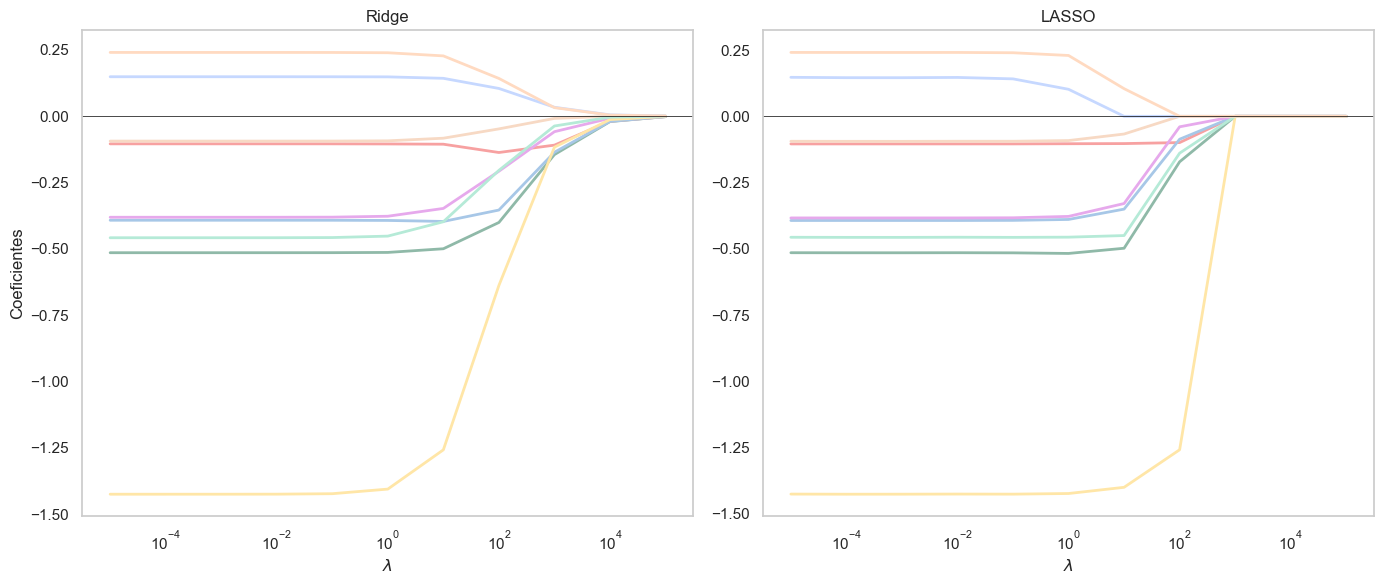

In [16]:
colores = [
    "#8FB9A8", "#F7A1A1", "#A7C7E7", "#F7D9C4", "#E6A9EC",
    "#FFE6A7", "#C6D8FF", "#B5EAD7", "#FFDAC1", "#E2F0CB"
]

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

#Ridge 
for i, col in enumerate(X_train.columns):
    axs[0].plot(lambdas, coefs_ridge[:, i], 
                color=colores[i % len(colores)], linewidth=2)
    
axs[0].set_xscale('log')
axs[0].set_xlabel(r'$\lambda$')
axs[0].set_ylabel('Coeficientes')
axs[0].set_title('Ridge')
axs[0].axhline(0, color='black', linewidth=0.5)
axs[0].grid(False)

#LASSO
for i, col in enumerate(X_train.columns):
    axs[1].plot(lambdas, coefs_lasso[:, i], 
                color=colores[i % len(colores)], linewidth=2)

axs[1].set_xscale('log')
axs[1].set_xlabel(r'$\lambda$')
axs[1].set_title('LASSO')
axs[1].axhline(0, color='black', linewidth=0.5)
axs[1].grid(False)

plt.tight_layout()
plt.show()

In [18]:
#Matriz de Ridge para ver como se va comprimiendo los coeficientes a medida que aumenta lambda

coefs_ridge = []

for C in Cs:
    model = LogisticRegression(penalty='l2',C=C,solver='lbfgs', max_iter=500)
    model.fit(X_train, y_train)
    coefs_ridge.append(model.coef_[0])

coefs_ridge = np.array(coefs_ridge)
coefs_ridge

array([[-5.15035836e-01, -1.04687880e-01, -3.92669351e-01,
        -9.43490135e-02, -3.81427254e-01, -1.42535500e+00,
         1.48238787e-01, -4.58631136e-01,  2.39900726e-01],
       [-5.15035705e-01, -1.04687887e-01, -3.92669417e-01,
        -9.43488986e-02, -3.81426901e-01, -1.42535328e+00,
         1.48238697e-01, -4.58630513e-01,  2.39900596e-01],
       [-5.15034391e-01, -1.04687963e-01, -3.92670074e-01,
        -9.43477497e-02, -3.81423373e-01, -1.42533603e+00,
         1.48237792e-01, -4.58624287e-01,  2.39899295e-01],
       [-5.15021252e-01, -1.04688718e-01, -3.92676644e-01,
        -9.43362632e-02, -3.81388100e-01, -1.42516359e+00,
         1.48228750e-01, -4.58562038e-01,  2.39886288e-01],
       [-5.14889915e-01, -1.04696433e-01, -3.92741999e-01,
        -9.42217146e-02, -3.81035922e-01, -1.42344184e+00,
         1.48138576e-01, -4.57940706e-01,  2.39756315e-01],
       [-5.13997423e-01, -1.05083058e-01, -3.93403531e-01,
        -9.33990966e-02, -3.77569640e-01, -1.406068

In [82]:
#Matriz de Lasso. En este caso se ve como se van haciendo cero

coefs_lasso = []

for C in Cs:
    model = LogisticRegression(penalty='l1',C=C,solver='liblinear',max_iter=500)
    model.fit(X_train, y_train)
    coefs_lasso.append(model.coef_[0])

coefs_lasso = np.array(coefs_lasso)
coefs_lasso

array([[-0.51461525, -0.10415129, -0.39308894, -0.09410272, -0.38336231,
        -1.42521079,  0.14723692, -0.45630299,  0.24118035],
       [-0.51483321, -0.1041415 , -0.39295613, -0.09443565, -0.38343031,
        -1.42572145,  0.14586759, -0.45678221,  0.24088012],
       [-0.51482995, -0.10416566, -0.39293722, -0.09437501, -0.38344342,
        -1.42581866,  0.14579412, -0.45677748,  0.24090918],
       [-0.51488866, -0.10413541, -0.39293484, -0.09433513, -0.38338938,
        -1.42574273,  0.14527539, -0.45675261,  0.24082935],
       [-0.51514392, -0.10406772, -0.39256707, -0.09413324, -0.38288967,
        -1.42552238,  0.14110137, -0.45665319,  0.23977878],
       [-0.51738646, -0.10343975, -0.38913421, -0.09147108, -0.3776126 ,
        -1.42315489,  0.10187567, -0.45601122,  0.22963099],
       [-0.497768  , -0.10286785, -0.35018531, -0.0668184 , -0.32900236,
        -1.39969408,  0.        , -0.44978304,  0.10436761],
       [-0.17160873, -0.09909987, -0.08644255,  0.        , -0

## 2.Penalidad óptima por Cross-validation y visualización

In [19]:
# Ridge

kf = KFold(n_splits=5, shuffle=True, random_state=100)

resultados = []

for C in Cs:
    errores = []
    
    for train_index, val_index in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
        y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

        modelo = LogisticRegression(penalty='l2', C=C, solver='lbfgs', max_iter=500)
        modelo.fit(X_tr, y_tr)
        prediccion = modelo.predict(X_val)
        
        acc = accuracy_score(y_val, prediccion)
        error = 1 - acc
        errores.append(error)
    
    resultados.append(np.mean(errores))

mejor_ridge = np.argmin(resultados)
mejor_lambda_ridge = lambdas[mejor_ridge]
mejor_error_ridge = resultados[mejor_ridge]

print("Mejor lambda en Ridge:", mejor_lambda_ridge)
print("Menor error de clasificación en Ridge:", round(mejor_error_ridge, 4))

Mejor lambda en Ridge: 1.0
Menor error de clasificación en Ridge: 0.1927


In [20]:
# LASSO
kf = KFold(n_splits=5, shuffle=True, random_state=100)

resultados_lasso = []

for C in Cs:
    errores = []    
    for train_index, val_index in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
        y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

        modelo = LogisticRegression(penalty='l1',C=C,solver='liblinear',max_iter=500)
        modelo.fit(X_tr, y_tr)
        prediccion = modelo.predict(X_val)
        
        acc = accuracy_score(y_val, prediccion)
        error = 1 - acc
        errores.append(error)
    
    resultados_lasso.append(np.mean(errores))

mejor_lasso = np.argmin(resultados_lasso)
mejor_lambda_lasso = lambdas[mejor_lasso]
mejor_error_lasso = resultados_lasso[mejor_lasso]

print("Mejor lambda en LASSO:", mejor_lambda_lasso)
print("Menor error de clasificación en LASSO:", round(mejor_error_lasso, 4))

Mejor lambda en LASSO: 1e-05
Menor error de clasificación en LASSO: 0.193


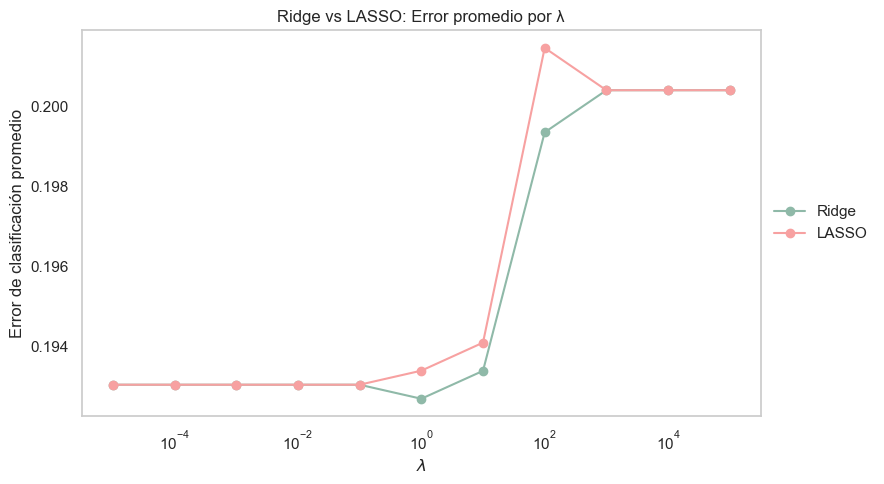

In [21]:
plt.figure(figsize=(9,5))
color_ridge = '#8FB9A8'   # verde pastel suave
color_lasso = '#F7A1A1'   # rojo pastel suave
plt.plot(lambdas, resultados, marker='o', linestyle='-', label='Ridge', color=color_ridge)
plt.plot(lambdas, resultados_lasso, marker='o', linestyle='-', label='LASSO', color=color_lasso)
plt.xscale('log')
plt.xlabel(r'$\lambda$')
plt.ylabel('Error de clasificación promedio')
plt.title('Ridge vs LASSO: Error promedio por λ')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
plt.grid(False)
plt.tight_layout()
plt.show()

## Estimación con lambda por cross-validation y comparación de coeficientes

In [22]:

logit = LogisticRegression(solver='lbfgs',max_iter=1000)
logit.fit(X_train, y_train)
coef_logit = logit.coef_[0]


lasso = LogisticRegression(penalty='l1',C=1/mejor_lambda_lasso,solver='liblinear', max_iter=1000)
lasso.fit(X_train, y_train)
coef_lasso = lasso.coef_[0]


ridge = LogisticRegression(penalty='l2', C=1/mejor_lambda_ridge,solver='lbfgs',max_iter=1000)
ridge.fit(X_train, y_train)
coef_ridge = ridge.coef_[0]

In [23]:
tabla_coef = pd.DataFrame({"Logit": coef_logit,"LASSO": coef_lasso,"Ridge": coef_ridge
}, index=X_train.columns)

tabla_coef.round(4)

,Logit,LASSO,Ridge
ch06,-0.51,-0.51,-0.51
educ,-0.11,-0.10,-0.11
educ_jefe,-0.39,-0.39,-0.39
Sexo_Varón,-0.09,-0.09,-0.09
estado_Ocupado,-0.38,-0.38,-0.38
cobertura_medica_tiene,-1.41,-1.43,-1.41
estado_civil_no_casado,0.15,0.15,0.15
jefe_ocupado,-0.45,-0.46,-0.45
jefe_mujer,0.24,0.24,0.24


In [24]:
tabla_coef.to_excel("coeficientes_logit_lasso_ridge.xlsx", index=True)

# B. Árboles de Decisión

## 4. Árbol podado con Cross-Validation (10-fold)

In [27]:
# === Librerías ===
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

In [28]:
# === Generar la grilla de ccp_alpha ===
# Grilla de valores para ccp_alpha (log-spaced)
ccp_grid = np.logspace(-5, 0, 20)   # desde 1e-5 hasta 1

In [29]:
# === Cross-validation 10-fold para seleccionar el mejor alpha ===
cv_errors = []

for alpha in ccp_grid:
    tree = DecisionTreeClassifier(random_state=100, ccp_alpha=alpha)
    scores = cross_val_score(tree, X_train, y_train, cv=10, scoring="accuracy")
    
    # Error = 1 - accuracy
    cv_errors.append(1 - scores.mean())

cv_errors = np.array(cv_errors)

best_alpha = ccp_grid[np.argmin(cv_errors)]
best_alpha

np.float64(0.002335721469090121)

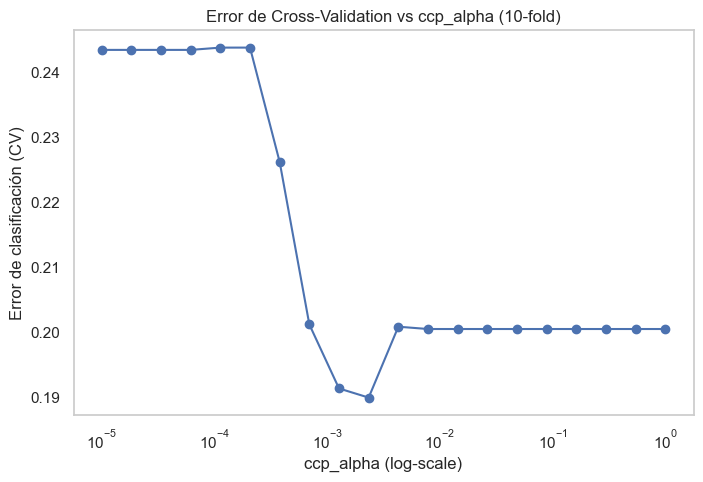

Mejor ccp_alpha según CV: 0.002335721469090121


In [30]:
# === Gráfico del error en función de ccp_alpha ===
plt.figure(figsize=(8,5))
plt.plot(ccp_grid, cv_errors, marker="o")
plt.xscale("log")
plt.xlabel("ccp_alpha (log-scale)")
plt.ylabel("Error de clasificación (CV)")
plt.title("Error de Cross-Validation vs ccp_alpha (10-fold)")
plt.grid(False)
plt.show()

print("Mejor ccp_alpha según CV:", best_alpha)

## 5. Visualización del árbol podado + Importancia de predictores

In [32]:
# === Entrenar el CART final con el mejor alpha ===
tree_pruned = DecisionTreeClassifier(random_state=100, ccp_alpha=best_alpha)
tree_pruned.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.002335721469090121),
                       random_state=100)

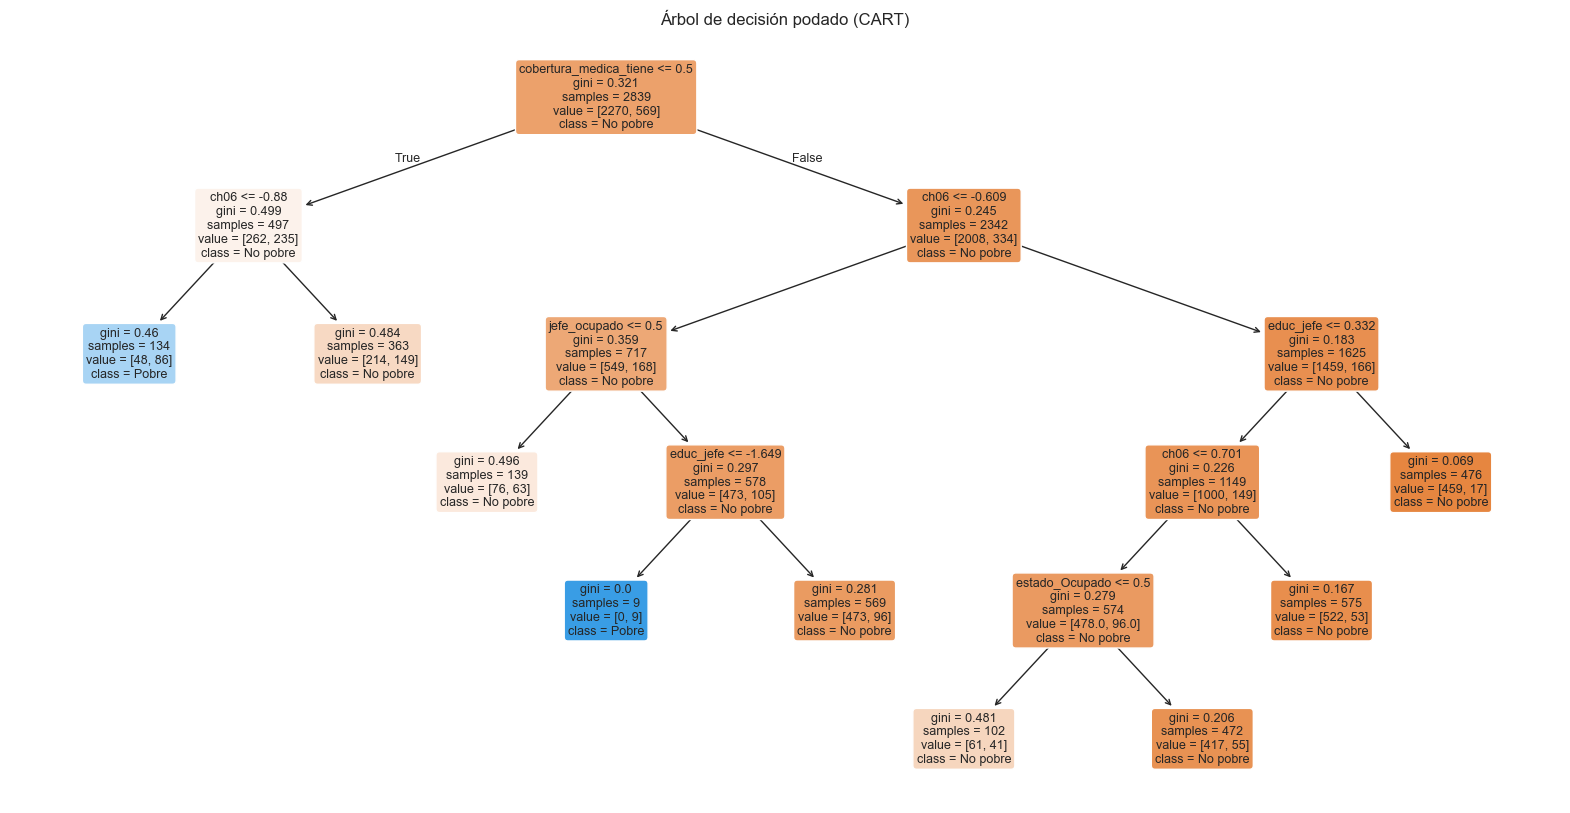

In [33]:
# === Visualizar el árbol podado ===
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(tree_pruned, 
          feature_names=X_train.columns,
          class_names=["No pobre", "Pobre"],
          filled=True,
          rounded=True,
          fontsize=9)
plt.title("Árbol de decisión podado (CART)")
plt.show()

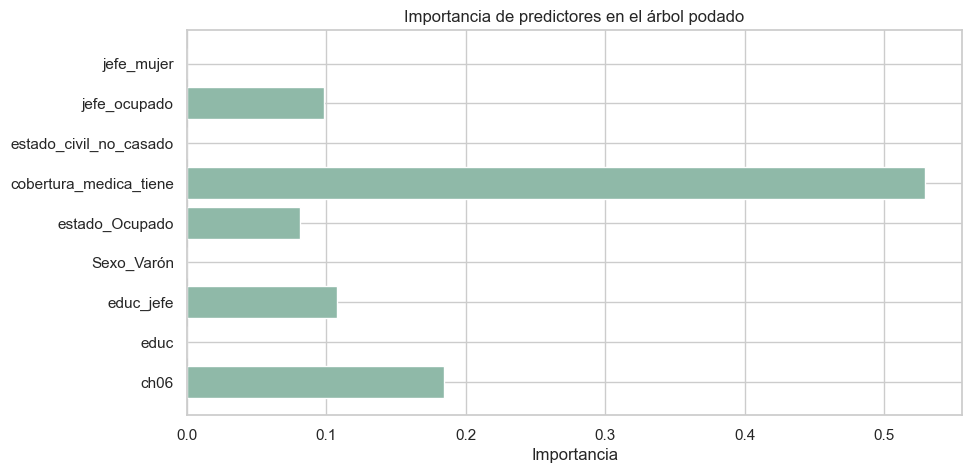

,Variable,Importancia
5,cobertura_medica_tiene,0.53
0,ch06,0.18
2,educ_jefe,0.11
7,jefe_ocupado,0.10
4,estado_Ocupado,0.08
3,Sexo_Varón,0.00
1,educ,0.00
6,estado_civil_no_casado,0.00
8,jefe_mujer,0.00


In [34]:
# === Importancia de predictores === 
importancias = tree_pruned.feature_importances_

plt.figure(figsize=(10,5))
plt.barh(X_train.columns, importancias, color="#8FB9A8")
plt.xlabel("Importancia")
plt.title("Importancia de predictores en el árbol podado")
plt.show()

pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": importancias
}).sort_values("Importancia", ascending=False)